# ESA Anomaly Dataset, Mission 2: analysis

## What the dataset contains

The ESA Anomaly Dataset is real satellite telemetry from three European Space
Agency missions, annotated by spacecraft operations engineers and cross-checked by
machine-learning experts. It is the product of an 18-month project by Airbus
Defence and Space, KP Labs and ESA's European Space Operations Centre, published
with a benchmark that was designed to replace the older spacecraft datasets whose
labelling was shown to be unreliable.

This notebook looks at **Mission 2**: 100 telemetry channels sampled over three and
a half years, from January 2000 to June 2003.

## Where to download it

> **Zenodo:** <https://doi.org/10.5281/zenodo.12528696> (v2: `10.5281/zenodo.15237121`)
> **Code and benchmark:** <https://github.com/kplabs-pl/ESA-ADB>
> **Paper:** <https://arxiv.org/abs/2406.17826>

Each mission ships as its own archive of roughly 3.8 GB. The licence is CC BY 3.0
IGO.

## What the raw data is not

**It is not a table.** Each channel is a separate pickled pandas series on its own
irregular time index, and the sampling rates differ by more than three orders of
magnitude — one channel reports 7.4 million times over the period while another
reports 1,703 times, roughly twice a day. There is no rectangular view of this
dataset until one is built.

**The labels are not a column.** They are intervals: `labels.csv` says that an
annotation with a given ID covers a stretch of time *on a particular channel*, and
`anomaly_types.csv` says whether that ID is an `Anomaly` or a `Rare Event`.

So the table read below is the output of `dencast/data/preprocess/preprocess_esa.py`,
which puts every channel on a common 18-second grid with zero-order hold — each
channel holds its last reported value until it reports a new one — and turns the
annotation intervals into per-row label columns.

The hold only works forward. Before a channel's first reading there is nothing to
hold, and the cell is left **NaN** rather than filled with the value that arrives
later: a guess at what an instrument read before it was reporting is
indistinguishable from a measurement once it sits in the table, and the whole point
of the alignment checks in `preprocess.py` is that this dataset should contain
nothing indistinguishable from a measurement that is not one. Section 4 measures
where those holes are; section 3 measures the consequence of the hold itself.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

TABLE = Path("../data/interim/esa/full_esa.parquet")
META = Path("../data/raw/esa/ESA-Mission2")
# The value columns are 2.5 GB at full resolution. Statistics that describe shape
# rather than individual instants are computed on every STRIDE-th row, which is
# stated wherever it matters; the labels are always read whole, because a segment
# boundary is exactly the thing a subsample would blur.
STRIDE = 10

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NORMAL, ANOM = C[0], "#d03b3b"
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 1.6, "figure.dpi": 110,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})
print("pandas", pd.__version__, "| matplotlib", mpl.__version__)

pandas 2.2.3 | matplotlib 3.9.2


---
## 1. The files

One file, built once over the whole recording. Narrower date windows are cut from
it rather than rebuilt, because resampling 100 channels is minutes of work and a
date range is seconds.

In [2]:
f = pq.ParquetFile(TABLE)
names = list(f.schema_arrow.names)
channels = [c for c in names if c.startswith("channel_")]
label_cols = [c for c in names if c.startswith("label_")]
flags = [c for c in names if c.startswith("is_")]

print(f"{TABLE.name}: {f.metadata.num_rows:,} rows x {f.metadata.num_columns} columns")
print(f"  {len(channels)} channels, {len(label_cols)} per-channel labels, "
      f"{len(flags)} global flags: {', '.join(flags)}")
print(f"  {f.metadata.num_row_groups} row groups, "
      f"{TABLE.stat().st_size / 2**30:.2f} GB on disk")

# Only the two global flags, so the index and the segments cost almost nothing.
lab = pd.read_parquet(TABLE, columns=flags)
step = pd.Series(lab.index).diff().dropna()
print(f"\n  from {lab.index.min()} to {lab.index.max()}")
print(f"  {(lab.index.max() - lab.index.min()).days:,} days at a step of "
      f"{step.median().total_seconds():.0f} s, irregular intervals: "
      f"{int((step != step.median()).sum())}")

full_esa.parquet: 6,129,600 rows x 203 columns
  100 channels, 100 per-channel labels, 2 global flags: is_anomaly, is_rare_event
  16 row groups, 0.35 GB on disk

  from 2000-01-01 00:00:00 to 2003-06-30 23:59:42
  1,276 days at a step of 18 s, irregular intervals: 0


**The file is a ninth of its size in memory.** 6.1 million rows by 202 columns is
about 3 GB once loaded and 0.35 GB on disk. The compression
ratio is itself a finding rather than an accident of the format: a third of the
channels report so rarely that, held forward onto an 18-second grid, they are long
runs of one repeated value — and a run of identical values is the easiest thing a
columnar format can store. Section 3 measures how many channels those are.

---
## 2. How the recording is ordered

HAI ships six runs that have to be checked for overlap before anything can be
concatenated, and SWaT ships one file that turns out to be three blocks out of order.
ESA ships a single numeric campaign, so the equivalent question is not how the
pieces fit together but whether the axis the preprocessing laid down is regular: one
row every eighteen seconds, no gaps, no instant appearing twice.

In [3]:
# One recording, not six. ESA ships a single numeric campaign rather than a set
# of runs, so the question HAI answers with a file-by-file timeline is answered here
# by whether the grid the preprocessing laid down is actually regular.
step = np.diff(lab.index.to_numpy()).astype("timedelta64[s]").astype("int64")
print(f"from {lab.index[0]} to {lab.index[-1]}")
print(f"   {len(lab):,} rows over {(lab.index[-1] - lab.index[0]).days:,} days")
print(f"   timestamps unique: {lab.index.is_unique}   monotonic: "
      f"{lab.index.is_monotonic_increasing}")
print(f"   intervals other than {int(np.median(step))} s: {int((step != np.median(step)).sum())}")
print(f"   rows expected from the span: "
      f"{int((lab.index[-1] - lab.index[0]).total_seconds() // np.median(step)) + 1:,}")

from 2000-01-01 00:00:00 to 2003-06-30 23:59:42
   6,129,600 rows over 1,276 days
   timestamps unique: True   monotonic: True
   intervals other than 18 s: 0
   rows expected from the span: 6,129,600


**The axis is exact.** 6,129,600 rows for 6,129,600 expected from the span, not one
interval other than 18 seconds, no repeated timestamp. That is a property of how the
table was built rather than a discovery about the data -- the index is a `date_range`
the preprocessing generated -- but it is checked rather than assumed, because a
construction is only as good as the code that ran it, and the reason to check is the
other two datasets: SWaT needed re-ordering and de-duplicating before anything else
could be measured.

---
## 3. Which variables are present

Three things decide what the channels can be used for: what `channels.csv` declares
each one to be, how much each one actually moves on the grid, and how fast each one
reports in the raw archive -- which is what fixes the grid in the first place.

In [4]:
meta = pd.read_csv(META / "channels.csv")
meta = meta[meta["Channel"].isin(channels)].reset_index(drop=True)

print("by subsystem:")
print(meta.groupby("Subsystem").agg(
    channels=("Channel", "size"),
    target=("Target", lambda s: (s == "YES").sum()),
    categorical=("Categorical", lambda s: (s == "YES").sum()),
).to_string())
print(f"\n  scored by the benchmark (Target=YES): {(meta.Target == 'YES').sum()} of {len(meta)}")
print(f"  categorical: {(meta.Categorical == 'YES').sum()}")

by subsystem:
             channels  target  categorical
Subsystem                                 
subsystem_1        57      20            2
subsystem_2         3       3            0
subsystem_4         9       0            7
subsystem_5        19      16            1
subsystem_6        12       8            0

  scored by the benchmark (Target=YES): 47 of 100
  categorical: 10


In [5]:
# Read row group by row group and keep every STRIDE-th row, so the peak is one
# group rather than the whole 2.5 GB of values.
parts = []
for g in range(f.metadata.num_row_groups):
    parts.append(f.read_row_group(g, columns=channels).to_pandas().iloc[::STRIDE])
V = pd.concat(parts)
del parts
print(f"subsample for the statistics below: {len(V):,} rows "
      f"(every {STRIDE}th, {STRIDE * 18} s apart)")

levels = V.nunique()
# How often a channel actually moves. On a grid built by zero-order hold this is
# the quantity that separates a signal from a staircase: a channel that reports
# twice a day changes on one row in 2,400 and repeats itself on the rest.
# The denominator is the rows where the channel reports at all, not every row:
# with the lead-in left as NaN, dividing by the full height would make a channel
# look more static merely for having started late.
updates = (V.diff().ne(0) & V.notna()).sum() / V.notna().sum()
summary = pd.DataFrame({"levels": levels, "update rate": updates})
print()
print("distinct values per channel: min %d, median %.0f, max %s"
      % (levels.min(), levels.median(), f"{levels.max():,}"))
print("update rate   : 25%% %.5f | median %.3f | 75%% %.3f"
      % (updates.quantile(.25), updates.median(), updates.quantile(.75)))
print()
for thr, lbl in ((0.001, "under 0.1%"), (0.01, "under 1%"), (0.5, "under 50%")):
    print(f"  channels moving on {lbl} of rows: {int((updates < thr).sum())}")
print()
print("the ten most static channels:")
print(summary.nsmallest(10, "update rate").to_string())

subsample for the statistics below: 612,960 rows (every 10th, 180 s apart)

distinct values per channel: min 2, median 422, max 495,738
update rate   : 25% 0.00076 | median 0.204 | 75% 0.882

  channels moving on under 0.1% of rows: 29
  channels moving on under 1% of rows: 31
  channels moving on under 50% of rows: 63

the ten most static channels:
            levels  update rate
channel_32       2     0.000003
channel_37       2     0.000003
channel_29       3     0.000005
channel_30       3     0.000005
channel_33       3     0.000005
channel_36       3     0.000005
channel_31       4     0.000007
channel_34       4     0.000007
channel_35       4     0.000007
channel_46      12     0.000020


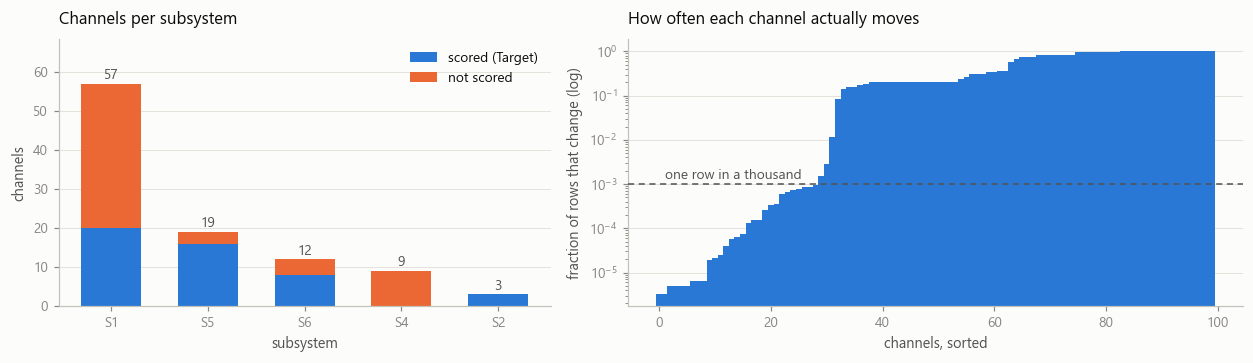

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.4), gridspec_kw={"width_ratios": [1, 1.25]})

# Left: channels per subsystem, split by whether the benchmark scores them. Two
# series, so two colours and a legend; stacked because the parts sum to a total.
piv = (meta.assign(scored=np.where(meta.Target == "YES", "scored", "not scored"))
           .groupby(["Subsystem", "scored"]).size().unstack(fill_value=0)
           .reindex(columns=["scored", "not scored"], fill_value=0))
piv = piv.loc[piv.sum(axis=1).sort_values(ascending=False).index]
x = np.arange(len(piv))
ax1.bar(x, piv["scored"], color=C[0], width=0.62, label="scored (Target)")
ax1.bar(x, piv["not scored"], bottom=piv["scored"], color=C[1], width=0.62, label="not scored")
for i, t in enumerate(piv.sum(axis=1)):
    ax1.text(i, t + 1.2, str(int(t)), ha="center", color=INK2, fontsize=9)
ax1.set_xticks(x, [s.replace("subsystem_", "S") for s in piv.index])
ax1.set(xlabel="subsystem", ylabel="channels", title="Channels per subsystem",
        ylim=(0, piv.sum(axis=1).max() * 1.2))
ax1.grid(axis="x", visible=False)
ax1.legend(loc="upper right")

# Right: how often each channel moves, sorted, on a log axis -- the range runs from
# one row in ten thousand to almost every row, and a linear axis would flatten the
# static two-thirds against zero.
u = np.sort(updates.to_numpy())
u = np.clip(u, 1e-6, None)
ax2.bar(range(len(u)), u, color=C[0], width=1.0)
ax2.set_yscale("log")
ax2.axhline(0.001, color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)
ax2.text(1, 0.0013, "one row in a thousand", color=INK2, fontsize=9)
ax2.set(xlabel="channels, sorted", ylabel="fraction of rows that change (log)",
        title="How often each channel actually moves")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

### Why the grid is 18 seconds

The resampling rule is the one choice in the preprocessing that cannot be undone
afterwards: too fine and it invents rows, too coarse and it throws readings away. The
raw channels decide it, so this asks them.

In [7]:
# The only cell that touches the raw archive rather than the interim table: it opens
# all 100 channel files to read their native timestamps, which takes about two and a
# half minutes. Each series is freed before the next is opened.
GRID_S = 18
rows = []
for i in range(1, len(channels) + 1):
    ser = pd.read_pickle(META / "channels" / f"channel_{i}.zip")
    gaps = np.diff(ser.index.to_numpy()).astype("timedelta64[s]").astype("int64")
    rows.append((f"channel_{i}", len(ser), int(np.median(gaps)), float(gaps.mean())))
    del ser, gaps

native = pd.DataFrame(rows, columns=["channel", "readings", "median_gap_s",
                                     "mean_gap_s"]).set_index("channel")
native["per_row"] = native.readings / f.metadata.num_rows

print("native median interval -> channels:")
for g, grp in native.groupby("median_gap_s"):
    kind = "downsampled by the grid" if grp.per_row.mean() > 1 else "held forward"
    print(f"   {g:>6,} s   {len(grp):>3} channels   "
          f"{grp.readings.mean():>12,.0f} readings each   "
          f"{grp.per_row.mean():>8.4f} per grid row   {kind}")
print()
print(f"the grid has {f.metadata.num_rows:,} rows at {GRID_S} s")
print(f"the modal native interval is {int(native.median_gap_s.mode()[0])} s, "
      f"shared by {int((native.median_gap_s == GRID_S).sum())} of {len(native)} channels")
print()
# Does a flat channel on the grid mean a slowly sampled one? This is the answer.
flat = updates[updates < 0.001].index
print(f"the {len(flat)} channels moving on under one row in a thousand report natively at: "
      f"{native.loc[flat, 'median_gap_s'].value_counts().to_dict()}")

native median interval -> channels:
        3 s     3 channels     32,431,335 readings each     5.2909 per grid row   downsampled by the grid
       18 s    92 channels      7,379,859 readings each     1.2040 per grid row   downsampled by the grid
      900 s     4 channels        122,914 readings each     0.0201 per grid row   held forward
   64,800 s     1 channels          1,703 readings each     0.0003 per grid row   held forward

the grid has 6,129,600 rows at 18 s
the modal native interval is 18 s, shared by 92 of 100 channels

the 29 channels moving on under one row in a thousand report natively at: {18: 29}


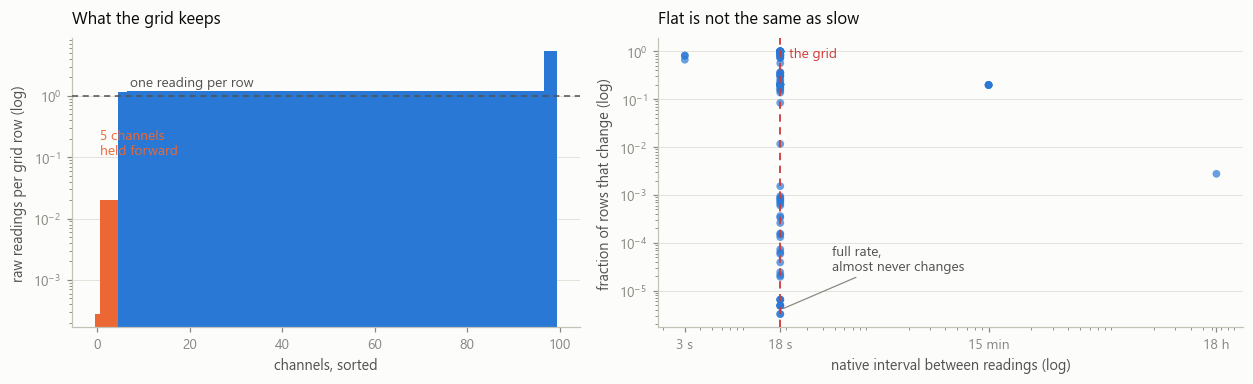

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.6),
                               gridspec_kw={"width_ratios": [1, 1.15]})

# Left: readings kept per grid row. Above the line the grid discards readings, below
# it the same reading is copied across many rows. Log axis: the range is four orders.
pr = np.sort(native.per_row.to_numpy())
ax1.bar(range(len(pr)), pr, color=np.where(pr > 1, C[0], C[1]), width=1.0)
ax1.set_yscale("log")
ax1.axhline(1.0, color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)
# Both labels go in the empty regions: above the line but left of the tall bars,
# and above the five held channels, which top out at 0.02.
ax1.text(7, 1.45, "one reading per row", color=INK2, fontsize=9)
ax1.text(0.5, 0.10, "5 channels\nheld forward", color=C[1], fontsize=9, va="bottom")
ax1.set(xlabel="channels, sorted", ylabel="raw readings per grid row (log)",
        title="What the grid keeps")
ax1.grid(axis="x", visible=False)

# Right: native interval against how often the channel changes on the grid. The
# question it settles is whether a flat channel is flat because it is sampled rarely.
# If it were, the points would lie on a falling diagonal. They do not.
ax2.scatter(native.median_gap_s, updates.reindex(native.index),
            s=26, color=C[0], alpha=0.7, edgecolor="none")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.axvline(GRID_S, color=ANOM, linewidth=1.2, linestyle=(0, (4, 3)), zorder=3)
ax2.annotate("the grid", xy=(GRID_S, 0.9), xytext=(6, 0), textcoords="offset points",
             color=ANOM, fontsize=9, va="center")
ax2.annotate("full rate,\nalmost never changes", xy=(GRID_S, 4e-6),
             xytext=(34, 26), textcoords="offset points", color=INK2, fontsize=9,
             arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8))
ax2.set_xticks([3, 18, 900, 64800], ["3 s", "18 s", "15 min", "18 h"])
ax2.set(xlabel="native interval between readings (log)",
        ylabel="fraction of rows that change (log)",
        title="Flat is not the same as slow")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**18 seconds is the modal native rate: 92 of the 100 channels report at exactly that
interval.** That is the whole justification, and it is the right kind of one -- it is
the grid that leaves the largest group of channels untouched. Anything finer would
fabricate rows for those 92; anything coarser would discard readings they did send.

The other eight divide into two kinds, treated in opposite ways:

| native interval | channels | readings each | per grid row | effect |
|---|---|---|---|---|
| 3 s | `channel_63`-`channel_65` | 32,431,335 | 5.29 | **81% of readings discarded** |
| 18 s | the other 92 | ~7.4 million | 1.20 | 17% discarded |
| 15 min | `channel_66`-`channel_69` | 122,914 | 0.020 | each reading copied across ~50 rows |
| 18 h | `channel_100` | 1,703 | 0.0003 | each reading copied across ~3,600 rows |

Two rows of that table are worth not skipping.

**Three channels are sampled six times faster than the grid.** `channel_63` to
`channel_65` report every 3 seconds, and an 18-second grid keeps one reading in six:
26 million readings per channel are dropped. If an anomaly on those channels lives in
the sub-18-second structure, this table cannot show it and no model built on this
table can find it. That is a ceiling set by the resampling rule, and it is worth
knowing it is there before concluding that a method failed on them.

**Even the 92 lose 17%.** Their median gap is 18 s but their mean is 14.8 s, because
the distribution has a short tail -- the tenth percentile is 2 seconds. They report in
bursts, and the grid keeps the last reading of each burst.

**About a third of the channels barely move.** On the 18-second grid, 29 of 100
change value on fewer than one row in a thousand, and the nine most static have
between two and four distinct values across three and a half years.

**They are flat because the instrument is flat, not because the grid stretched them.**
The natural guess is the opposite one, and the measurement above rules it out: all 29
report natively every 18 seconds, 7.4 million readings each, the same rate as the
busiest channels in the table. On the scatter they sit in the bottom-left corner --
full sampling rate, near-zero variation -- rather than along the falling diagonal that
slow sampling would produce. The one channel whose flatness the hold really does
manufacture is `channel_100`, which reports twice a day.

It still matters for anything computed over a window, but for a different reason. A
rolling standard deviation on such a channel is zero almost everywhere and spikes at
the single row where the value steps; a derivative is a train of isolated impulses.
These are near-discrete signals -- status words, mode flags, relay positions -- so a
feature that assumes a numeric quantity will describe them badly, and a distance
that weights every column equally will let two dozen almost-constant columns dilute
the ones carrying information.

---
## 4. Data quality

Two checks. Rows that repeat come first because that is where SWaT failed; holes come
second because that is where this dataset does.

### Rows that repeat

In [9]:
# Rows that repeat. Hashed one row group at a time rather than compared directly:
# the value columns are 2.5 GB and `duplicated` on all of them at once is a copy of
# that. A 64-bit hash over 6.1 million rows has a collision probability around one
# in a million, and every hit below is then confirmed exactly.
digest = []
for g in range(f.metadata.num_row_groups):
    blk = f.read_row_group(g, columns=channels).to_pandas()
    digest.append(pd.util.hash_pandas_object(blk, index=False).to_numpy())
    del blk
digest = np.concatenate(digest)

repeat = pd.Series(digest).duplicated(keep="first").to_numpy()
involved = np.flatnonzero(pd.Series(digest).duplicated(keep=False).to_numpy())
print(f"rows identical to an earlier row across all {len(channels)} channels: "
      f"{int(repeat.sum())} ({repeat.mean():.5%})")
print(f"rows sharing an exact timestamp: {int(lab.index.duplicated().sum())}")
print()
if len(involved):
    gap = np.diff(involved)
    adjacent = int((gap == 1).sum())
    print(f"{len(involved)} rows take part in a repeat, in "
          f"{len(involved) - int(repeat.sum())} distinct readings")
    print(f"   consecutive in time: {adjacent} of the {len(gap)} steps between them")
    print(f"   first {lab.index[involved[0]]}, last {lab.index[involved[-1]]}")
    exact = pd.read_parquet(TABLE, columns=channels).iloc[involved]
    print(f"   confirmed exactly, not by hash: "
          f"{int(exact.duplicated(keep=False).sum())} of {len(exact)}")
    del exact

rows identical to an earlier row across all 100 channels: 50 (0.00082%)
rows sharing an exact timestamp: 0

84 rows take part in a repeat, in 34 distinct readings
   consecutive in time: 47 of the 83 steps between them
   first 2000-01-13 00:29:24, last 2003-04-20 22:54:00
   confirmed exactly, not by hash: 84 of 84


**Nothing repeats that should not.** No two rows share a timestamp, which section 2
already established from the other direction.

50 rows out of 6.1 million are identical to an earlier row across all 100 channels,
and they are **not the SWaT defect**. There the duplicates were copies of rows from a
different part of the file, 34% of it, and a neighbourhood method would have found
each one at distance zero from its own copy. Here 47 of the 83 steps between the rows
involved are a single step: they are consecutive instants where no channel happened to
report a new value in eighteen seconds. That is a steady state, not a copy, and it is
what a zero-order hold on a hundred channels will occasionally produce.

### Where the table has no data

A channel that had not yet reported when the window opened has no value to hold
forward, so those rows are NaN. Nothing else produces one here: the raw channel
files contain no missing values at all, and once a channel starts reporting the hold
covers every row to the end. So the question this section has to answer is narrow
and answerable -- how much of the table is missing, which channels, and whether any
of it overlaps the part that matters.

In [10]:
# Streamed one row group at a time: the peak is a 400k x 100 block rather than the
# whole matrix.
nan = pd.Series(0, index=channels, dtype="int64")
for g in range(f.metadata.num_row_groups):
    nan += f.read_row_group(g, columns=channels).to_pandas().isna().sum()

N = f.metadata.num_rows
cells = N * len(channels)
print(f"NaN cells: {nan.sum():,} of {cells:,} ({nan.sum() / cells:.3%})")
print(f"  channels with at least one: {int((nan > 0).sum())} of {len(channels)}")
print(f"  channels with none        : {', '.join(nan[nan == 0].index)}")
print()
print("the six channels missing most, in rows and in time:")
for c, v in nan.sort_values(ascending=False).head(6).items():
    print(f"   {c:<12} {v:>9,} rows   {v * 18 / 3600:>9.2f} h   {v / N:7.3%} of the table")

# Only a handful of distinct lead-in lengths, so the coverage of the table over time
# is a short ladder rather than a distribution: this is the whole of it.
print()
print("channels present, cumulatively:")
present = 0
for rows, k in nan.value_counts().sort_index().items():
    present += int(k)
    print(f"   from row {rows:>8,}  (+{str(pd.to_timedelta(rows * 18, unit='s')):>16})  "
          f"{present:>3} channels")

NaN cells: 563,161 of 612,960,000 (0.092%)
  channels with at least one: 99 of 100
  channels with none        : channel_100

the six channels missing most, in rows and in time:
   channel_56     279,675 rows     1398.38 h    4.563% of the table
   channel_57     279,675 rows     1398.38 h    4.563% of the table
   channel_4        3,547 rows       17.73 h    0.058% of the table
   channel_67          43 rows        0.21 h    0.001% of the table
   channel_68          43 rows        0.21 h    0.001% of the table
   channel_66          43 rows        0.21 h    0.001% of the table

channels present, cumulatively:
   from row        0  (+ 0 days 00:00:00)    1 channels
   from row        1  (+ 0 days 00:00:18)   93 channels
   from row       43  (+ 0 days 00:12:54)   97 channels
   from row    3,547  (+ 0 days 17:44:06)   98 channels
   from row  279,675  (+58 days 06:22:30)  100 channels


In [11]:
# The claim worth checking before reading a NaN count as a lead-in: a NaN is never
# a dropout in the middle of the recording, only the stretch before the channel's
# first reading. If that failed anywhere, NaN would mean two different things and
# would need two different treatments.
worst = nan.sort_values(ascending=False).head(6).index.tolist()
W = pd.read_parquet(TABLE, columns=worst)
for c in worst:
    m = W[c].isna().to_numpy()
    k = int(m.sum())
    prefix = bool(m[:k].all()) and not bool(m[k:].any())
    print(f"   {c:<12} {k:>9,} NaN   prefix only: {str(prefix):<5}   "
          f"first reading {W.index[k]}  (+{W.index[k] - W.index[0]})")
del W

   channel_56     279,675 NaN   prefix only: True    first reading 2000-02-28 06:22:30  (+58 days 06:22:30)
   channel_57     279,675 NaN   prefix only: True    first reading 2000-02-28 06:22:30  (+58 days 06:22:30)
   channel_4        3,547 NaN   prefix only: True    first reading 2000-01-01 17:44:06  (+0 days 17:44:06)
   channel_67          43 NaN   prefix only: True    first reading 2000-01-01 00:12:54  (+0 days 00:12:54)
   channel_68          43 NaN   prefix only: True    first reading 2000-01-01 00:12:54  (+0 days 00:12:54)
   channel_66          43 NaN   prefix only: True    first reading 2000-01-01 00:12:54  (+0 days 00:12:54)


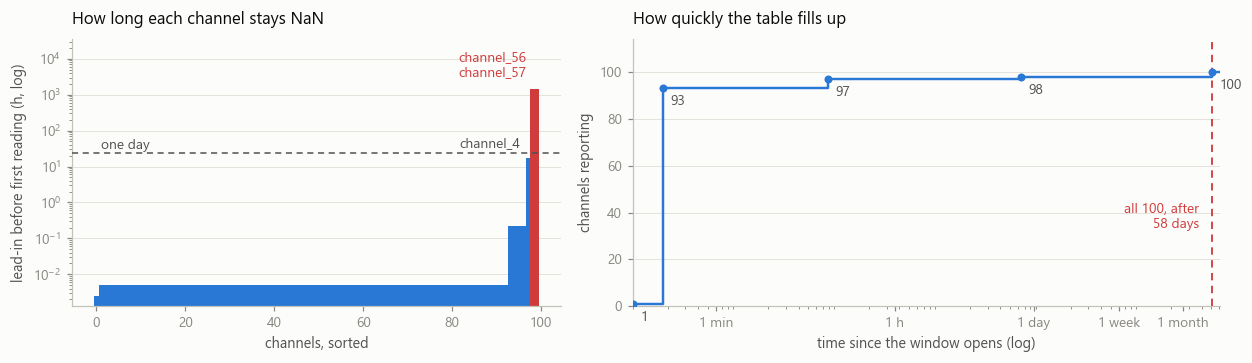

In [12]:
# Every NaN is a prefix, so the count per channel *is* the lead-in length.
lead = nan.reindex(channels).to_numpy()
lead_h = lead * 18 / 3600

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.4),
                               gridspec_kw={"width_ratios": [1, 1.2]})

# Left: lead-in per channel, sorted, log axis -- the range runs from one row to 58
# days, five orders of magnitude, and a linear axis would show two bars and 98
# invisible ones.
h = np.clip(np.sort(lead_h), 18 / 3600 / 2, None)
ax1.bar(range(len(h)), h, color=C[0], width=1.0)
ax1.bar(range(len(h))[-2:], h[-2:], color=ANOM, width=1.0)
ax1.set_yscale("log")
ax1.axhline(24, color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)
ax1.text(1, 30, "one day", color=INK2, fontsize=9)
# Name the three that matter. The other 97 are a single step and need no label.
ax1.annotate("channel_56\nchannel_57", xy=(len(h) - 1.5, h[-1]), xytext=(-5, 7),
             textcoords="offset points", ha="right", va="bottom",
             color=ANOM, fontsize=9)
ax1.annotate("channel_4", xy=(len(h) - 3, h[-3]), xytext=(-5, 5),
             textcoords="offset points", ha="right", va="bottom",
             color=INK2, fontsize=9)
ax1.set(xlabel="channels, sorted", ylabel="lead-in before first reading (h, log)",
        title="How long each channel stays NaN", ylim=(None, h.max() * 25))
ax1.grid(axis="x", visible=False)

# Right: the same numbers as the question actually asked of them -- from when is the
# table complete? A step function, one step per channel coming online.
# Elapsed time, log axis. On a calendar axis the first four rungs -- 18 s, 13 min,
# 18 h -- all land inside the first pixel and only the last one is visible, which
# tells the opposite of the truth: almost everything is present almost immediately.
ladder = nan.value_counts().sort_index()
secs = np.clip(ladder.index.to_numpy() * 18, 9, None)   # row 0 has no elapsed time
cum = ladder.to_numpy().cumsum()
END = 70 * 86400
ax2.step(np.r_[secs, END], np.r_[cum, cum[-1]], where="post", color=C[0])
ax2.scatter(secs, cum, s=18, color=C[0], zorder=4)
ax2.set_xscale("log")
for x, y in zip(secs, cum):
    ax2.annotate(f"{y}", xy=(x, y), xytext=(5, -11), textcoords="offset points",
                 color=INK2, fontsize=9)

ax2.axvline(secs[-1], color=ANOM, linewidth=1.2, linestyle=(0, (4, 3)), zorder=3)
ax2.annotate("all 100, after\n58 days", xy=(secs[-1], 38), xytext=(-8, 0),
             textcoords="offset points", ha="right", va="center",
             color=ANOM, fontsize=9)
ax2.set_xlim(9, END)
ax2.set_ylim(0, 114)
ax2.set_xticks([60, 3600, 86400, 7 * 86400, 30 * 86400],
               ["1 min", "1 h", "1 day", "1 week", "1 month"])
ax2.set(xlabel="time since the window opens (log)", ylabel="channels reporting",
        title="How quickly the table fills up")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

In [13]:
# What the lead-in costs if it is simply dropped -- the only honest option for a
# method that needs all 100 columns at once.
L = int(lead.max())
a0 = lab["is_anomaly"].to_numpy()
r0 = lab["is_rare_event"].to_numpy()
seg0 = np.flatnonzero(np.diff(np.r_[0, (a0 != 0).astype(int), 0]) == 1)
print(f"dropping the first {L:,} rows removes {L / N:.2%} of the recording")
print(f"  anomalous rows lost   : {int(a0[:L].sum()):,}")
print(f"  anomaly segments lost : {int((seg0 < L).sum())} of {len(seg0)}")
print(f"  rare-event rows lost  : {int(r0[:L].sum()):,} "
      f"({r0[:L].sum() / r0.sum():.1%} of all rare-event rows)")
print(f"\n  first anomaly begins {lab.index[seg0[0]]}, which is "
      f"{(lab.index[seg0[0]] - lab.index[L]).total_seconds() / 86400:.1f} days "
      f"after the last channel comes online")

dropping the first 279,675 rows removes 4.56% of the recording
  anomalous rows lost   : 0
  anomaly segments lost : 0 of 31
  rare-event rows lost  : 12,440 (5.3% of all rare-event rows)

  first anomaly begins 2000-03-01 04:59:06, which is 1.9 days after the last channel comes online


**The holes are 0.09% of the table and every one of them is at the start.** No
channel drops out mid-recording, which is what licenses reading a NaN count as a
lead-in length rather than as scattered missingness.

There are only **five distinct lead-in lengths** among the hundred channels, so the
coverage of the table is not a distribution but a five-rung ladder:

| from | which is | channels present |
|---|---|---|
| row 0 | 1 Jan 2000, 00:00:00 | 1 |
| row 1 | +18 s | 93 |
| row 43 | +12 min 54 s | 97 |
| row 3,547 | +17 h 44 min | 98 |
| row 279,675 | +58 d, i.e. 28 Feb 2000 | **100** |

The 92 channels that jump in at row 1 miss exactly one row, which is the grid's own
resolution rather than a real gap: their first reading falls inside the first
18 seconds but after midnight, so the opening cell has nothing to hold yet. Four more
(`channel_66` to `channel_69`) arrive 13 minutes in, `channel_4` after 17.7 hours, and
`channel_56` and `channel_57` after 58.3 days.

`channel_100` is the only channel with no NaN at all, which is the opposite of what
its sampling rate would suggest: it reports roughly twice a day, the slowest of the
hundred, but its first reading lands at or before midnight on 1 January, so the hold
covers it from row zero. A lead-in is a question of when a channel starts, not of how
often it speaks.

**Dropping the lead-in costs 4.6% of the rows and zero anomalies.** That is the
measurement that decides what to do about the NaN. A method needing all 100 columns
at once cannot begin before 28 February 2000, and cutting those rows loses no
anomalous row and none of the 31 segments, because the first anomaly starts 1.9 days
after the last channel comes online. It does lose 5.3% of the rare-event rows, which
matters only if rare events are being scored.

So the three options are not equally priced. Dropping the lead-in is cheap and loses
nothing that is being predicted. Imputing it buys 4.6% more training rows at the
price of 58 days of invented readings on two channels. Keeping the NaN and using a
method that tolerates them is free -- 93 channels are usable from the second row and
97 within thirteen minutes, and only two of the hundred are genuinely absent for the
first two months. That is why the NaN are left in the table rather than resolved by
the preprocessing:
the choice belongs to whoever reads the file, and it cannot be made after the fact
if the holes have already been filled in.

---
## 5. The anomalies

The dataset annotates 644 events across the whole recording, and the distinction
it draws between them is the first thing to look at: **613 are `Rare Event`, not
`Anomaly`**. Those are unusual but legitimate behaviours, annotated precisely so
that they would not be counted as faults. The preprocessing keeps them apart —
the per-channel label is 0 nominal, 1 anomaly, 2 rare event — so the decision of
what counts as a positive is still open here rather than baked in.

In [14]:
kinds = pd.read_csv(META / "anomaly_types.csv")
print("the 644 annotations, by category and shape:")
for col in ("Category", "Dimensionality", "Locality", "Length"):
    print(f"  {col:<16} {kinds[col].value_counts().to_dict()}")

def segments(y: np.ndarray):
    # Contiguous runs of positives, as (start, end) index pairs.
    ch = np.diff(np.r_[0, (y != 0).astype(int), 0])
    return np.flatnonzero(ch == 1), np.flatnonzero(ch == -1)

a = lab["is_anomaly"].to_numpy()
r = lab["is_rare_event"].to_numpy()
s, e = segments(a)
dur_h = (e - s) * 18 / 3600
print()
print(f"anomaly rows    : {int(a.sum()):,} ({a.mean():.3%}) in {len(s)} segments")
print(f"rare event rows : {int(r.sum()):,} ({r.mean():.3%})")
print(f"segment length (hours): min {dur_h.min():.2f} | median {np.median(dur_h):.2f} "
      f"| max {dur_h.max():.1f}")
print()
# The count is the check that the preprocessing lost nothing: the dataset declares
# 31 Anomaly events over the whole recording, and the table contains 31 runs.
print(f"declared Anomaly events: {int((kinds.Category == 'Anomaly').sum())}   "
      f"segments in the table: {len(s)}")
print()
print("segment starts by year:",
      pd.Series(lab.index[s]).dt.year.value_counts().sort_index().to_dict())

the 644 annotations, by category and shape:
  Category         {'Rare Event': 613, 'Anomaly': 31}
  Dimensionality   {'Multivariate': 635, 'Univariate': 9}
  Locality         {'Global': 585, 'Local': 59}
  Length           {'Subsequence': 644}

anomaly rows    : 106,143 (1.732%) in 31 segments
rare event rows : 235,320 (3.839%)
segment length (hours): min 0.13 | median 1.25 | max 465.2

declared Anomaly events: 31   segments in the table: 31

segment starts by year: {2000: 21, 2001: 5, 2002: 4, 2003: 1}


the longest segment lasts 465.2 hours (19.4 days) and alone covers 88% of all anomalous rows


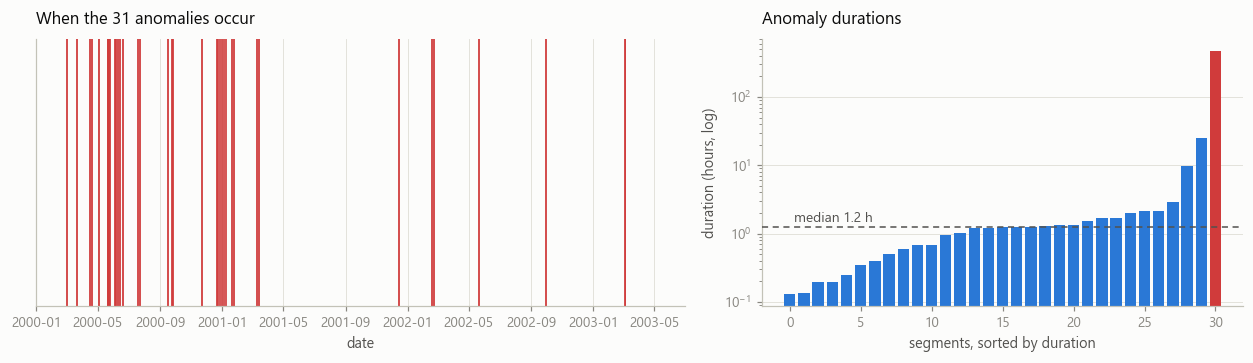

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.4), gridspec_kw={"width_ratios": [1.35, 1]})

# Left: where the anomalies fall over three and a half years. Two layers, because
# one would lose most of the data: the span is the true extent, but a two-hour span
# on an axis of 1,276 days is a fraction of a pixel and does not render at all, so
# every segment also gets a tick that is visible regardless of how short it is.
t = lab.index
for lo, hi in zip(s, e):
    ax1.axvspan(t[lo], t[min(hi, len(t) - 1)], color=ANOM, linewidth=0, alpha=0.85)
ax1.vlines(t[s], 0, 1, color=ANOM, linewidth=1.3, alpha=0.9)
ax1.set(yticks=[], ylim=(0, 1), xlabel="date",
        title=f"When the {len(s)} anomalies occur")
ax1.set_xlim(t.min(), t.max())
ax1.grid(axis="y", visible=False)

# Right: durations, sorted, log axis. The range is minutes to weeks.
order = np.sort(dur_h)
ax2.bar(range(len(order)), order, color=C[0], width=0.8)
ax2.bar([len(order) - 1], [order[-1]], color=ANOM, width=0.8)
ax2.set_yscale("log")
ax2.axhline(np.median(dur_h), color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)
ax2.text(0.3, np.median(dur_h) * 1.2, f"median {np.median(dur_h):.1f} h",
         color=INK2, fontsize=9)
ax2.set(xlabel="segments, sorted by duration", ylabel="duration (hours, log)",
        title="Anomaly durations")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

share = (e - s).max() / (e - s).sum()
print(f"the longest segment lasts {dur_h.max():.1f} hours ({dur_h.max()/24:.1f} days) "
      f"and alone covers {share:.0%} of all anomalous rows")

**One event dominates everything measured per row.** The longest anomaly runs for
weeks and accounts for the overwhelming majority of anomalous rows; after it, the
next longest lasts a few hours. So a metric computed per row — average precision,
pointwise F1 — is close to a measurement of whether that single event was caught,
with the other thirty contributing a few percent between them. A metric computed
per segment weighs them one each.

This is the same hazard that the point-adjusted convention introduces elsewhere,
arriving from the opposite direction: there a short detection is inflated into a
whole segment, here one enormous segment swamps the row count. Both are reasons to
report which convention is in use rather than a single number.

**And they are not spread evenly over the mission.** 21 of the 31 start in 2000, the
first year of the recording; the remaining ten are spread thinly over the following
two and a half years -- five in 2001, four in 2002, one in 2003 -- and the last
fifteen months contain a single event.

Whatever the cause (commissioning, a fault that was eventually fixed, or an
annotation effort that looked harder at the early data), the consequence for the
protocol is the same: **a chronological split does not produce two comparable
halves**. Training on the first year and testing on the rest means fitting the model
on the stretch where two thirds of the anomalies are and scoring it where they are
scarce, so the test base rate is not an estimate of the training one. That is worth
stating explicitly whenever a train/test boundary is drawn on this dataset.

         anomalies  anomalous rows share of rows
2000-03          2             438          0.4%
2000-04          2             569          0.5%
2000-05          5             821          0.8%
2000-06          5             890          0.8%
2000-07          2             337          0.3%
2000-09          3             618          0.6%
2000-11          1              26          0.0%
2000-12          1           50398         47.5%
2001-01          2           43142         40.6%
2001-03          2             650          0.6%
2001-12          1             269          0.3%
2002-02          2            2308          2.2%
2002-05          1             252          0.2%
2002-09          1            5089          4.8%
2003-03          1             336          0.3%

15 of the 42 months contain an anomaly; the busiest holds 5 of 31
the heaviest month, 2000-12, holds 47% of all anomalous rows; the busiest in events is 2000-05, a different month


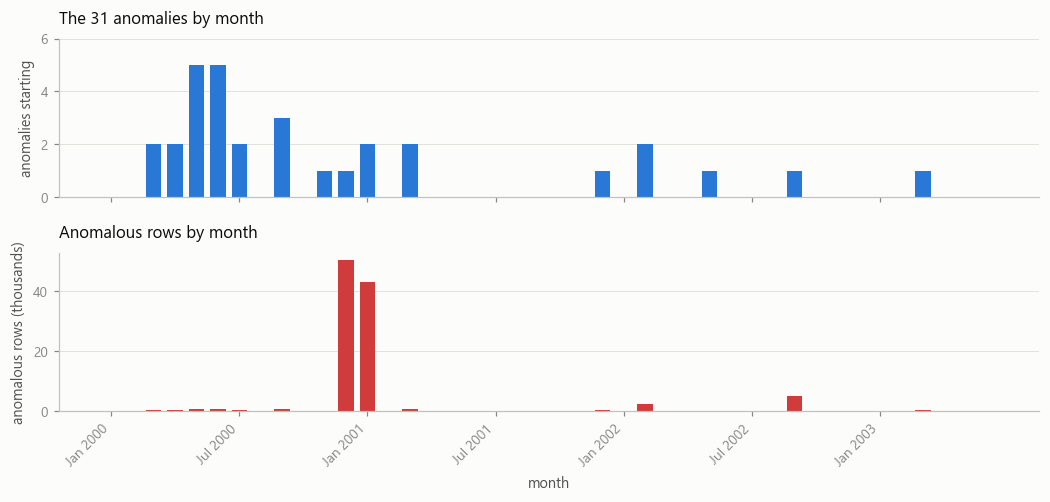

In [16]:
# When the anomalies happen. Three and a half years is too long for a bar per day,
# so the unit is the month; the second series is anomalous rows rather than events,
# because a month can be busy in events and light in mass and only the mass moves a
# per-row metric.
t = lab.index
starts = pd.Series(t[s]).dt.to_period("M")
mass = pd.Series(t[a.astype(bool)]).dt.to_period("M")
span = pd.period_range(t[0].to_period("M"), t[-1].to_period("M"), freq="M")
count = starts.value_counts().reindex(span, fill_value=0)
rows_m = mass.value_counts().reindex(span, fill_value=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 4.4), sharex=True,
                               gridspec_kw={"hspace": 0.35})
x = np.arange(len(span))
ax1.bar(x, count.to_numpy(), color=C[0], width=0.72)
ax1.set(ylabel="anomalies starting", title=f"The {len(s)} anomalies by month",
        ylim=(0, max(count.max() * 1.2, 1)))
ax1.grid(axis="x", visible=False)
ax2.bar(x, rows_m.to_numpy() / 1000, color=ANOM, width=0.72)
ax2.set(ylabel="anomalous rows (thousands)", xlabel="month",
        title="Anomalous rows by month")
ax2.grid(axis="x", visible=False)
ticks = [i for i, p in enumerate(span) if p.month in (1, 7)]
ax2.set_xticks(ticks, [span[i].strftime("%b %Y") for i in ticks],
               rotation=45, ha="right")
fig.tight_layout()
plt.show()

table = pd.DataFrame({"anomalies": count, "anomalous rows": rows_m})
table = table[table.sum(axis=1) > 0]
table["share of rows"] = (table["anomalous rows"] / rows_m.sum()).map("{:.1%}".format)
print(table.to_string())
print()
print(f"{int((count > 0).sum())} of the {len(span)} months contain an anomaly; "
      f"the busiest holds {count.max()} of {len(s)}")
same = count.idxmax() == rows_m.idxmax()
print(f"the heaviest month, {rows_m.idxmax()}, holds {rows_m.max() / rows_m.sum():.0%} "
      f"of all anomalous rows; the busiest in events is {count.idxmax()}"
      f"{', the same month' if same else ', a different month'}")

**The months with the most anomalies are not the months with the most anomalous
rows.** The events cluster in the first half of 2000 -- five in May, five in June --
while 88% of the anomalous rows fall in December 2000 and January 2001, two months
holding three events between them. That is the same 19-day segment the duration chart
picked out, seen from the other side: it straddles the year boundary, so it splits
across two bars and still dwarfs everything else.

15 of the 42 months contain an anomaly at all. The remaining 27 are nominal end to
end, which is worth knowing before splitting the recording by date: a chronological
cut can easily put every event on one side of it.

In [17]:
# How many channels each anomaly touches, from the labels themselves rather than
# the annotation file -- a cross-check that the per-channel columns agree with the
# global flag.
per_seg, involved = [], set()
cols = pd.read_parquet(TABLE, columns=label_cols)
arr = cols.to_numpy()
for lo, hi in zip(s, e):
    touched = np.flatnonzero((arr[lo:hi] == 1).any(axis=0))
    per_seg.append(len(touched))
    involved.update(touched.tolist())
del arr, cols
per_seg = np.array(per_seg)
print(f"channels touched per anomaly: min {per_seg.min()}, "
      f"median {np.median(per_seg):.0f}, max {per_seg.max()}")
print(f"anomalies on a single channel: {int((per_seg == 1).sum())} of {len(per_seg)}")
print(f"channels involved in at least one anomaly: {len(involved)} of {len(channels)}")

channels touched per anomaly: min 1, median 5, max 16
anomalies on a single channel: 9 of 31
channels involved in at least one anomaly: 38 of 100


---
## 6. Descriptive statistics

Everything in this section is computed on the **nominal rows only** -- 5,789,175 of
the 6,129,600, or 94.45%. The anomalies are excluded for the obvious reason and the
rare events for a less obvious one: they are legitimate behaviour, so they belong in
the dataset, but they are by definition not typical behaviour, and a baseline is
meant to be the typical thing.

The channels are described two ways because `channels.csv` says they are two kinds of
thing. Ten are declared `Categorical` and ninety are not. That declaration is used
here rather than a cardinality threshold, because ESA provides it and a threshold
would misclassify the static channels of section 3 -- which take two or three values
each and are nonetheless numeric quantities that happen not to move.

### The numeric channels

In [18]:
# Nominal rows only: these numbers are meant to describe the spacecraft when nothing
# is wrong with it, and the table contains 106,143 anomalous rows and 235,320 rare
# events. Rare events are excluded too -- they are legitimate behaviour, but they are
# not typical behaviour, and a baseline is supposed to be the second thing.
# The mask is built by walking the row groups with the same stride that built V,
# rather than by aligning on its index: selecting only the value columns leaves the
# datetime out of the frame, so V carries a positional index that would silently
# match nothing.
flags = []
for g in range(f.metadata.num_row_groups):
    blk = f.read_row_group(g, columns=["is_anomaly", "is_rare_event"]).to_pandas()
    blk = blk.iloc[::STRIDE]
    flags.append(((blk["is_anomaly"] == 0) & (blk["is_rare_event"] == 0)).to_numpy())
nominal = np.concatenate(flags)
assert len(nominal) == len(V)
declared = meta.set_index("Channel")["Categorical"]
cat_ch = [c for c in channels if declared.get(c) == "YES"]
con_ch = [c for c in channels if declared.get(c) == "NO"]

print(f"nominal rows in the subsample: {int(nominal.sum()):,} of {len(V):,} "
      f"({nominal.mean():.2%})")
print(f"   {len(con_ch)} numeric channels, {len(cat_ch)} categorical "
      f"(as `channels.csv` declares them, not by cardinality)")

desc = V.loc[nominal, con_ch].describe().T
desc[["count", "mean", "std", "min", "50%", "max"]].round(3)

nominal rows in the subsample: 578,925 of 612,960 (94.45%)
   90 numeric channels, 10 categorical (as `channels.csv` declares them, not by cardinality)


,count,mean,std,min,50%,max
channel_1,578924.0,0.569,0.277,0.001,0.631,0.999
channel_2,578924.0,0.499,0.001,0.281,0.499,0.501
channel_3,578924.0,0.500,0.000,0.498,0.500,0.624
channel_6,578924.0,1.000,0.000,1.000,1.000,1.000
channel_7,578924.0,0.010,0.000,0.004,0.010,0.018
channel_8,578924.0,0.015,0.000,0.012,0.015,0.021
channel_9,578924.0,0.502,0.022,0.414,0.501,0.570
channel_10,578924.0,0.476,0.102,0.012,0.462,0.927
channel_11,578924.0,0.555,0.048,0.348,0.545,0.866
channel_12,578924.0,0.507,0.000,0.505,0.507,0.508


### The categorical channels

Not a mean but a state: which level the channel sits in, how lopsided that is, and
how often it leaves.

In [19]:
# The categorical channels get the full series rather than the subsample: a
# transition is a single row, and every tenth row would undercount them by roughly
# the stride. Ten columns is 245 MB, which is affordable where a hundred would not be.
K = pd.read_parquet(TABLE, columns=cat_ch)
keep = ((lab["is_anomaly"] == 0) & (lab["is_rare_event"] == 0)).to_numpy()
K = K.loc[keep]

rows = []
for c in cat_ch:
    col = K[c].dropna()
    vc = col.value_counts(normalize=True)
    rows.append({"channel": c, "levels": int(col.nunique()),
                 "dominant state": float(vc.index[0]),
                 "dominant share": round(float(vc.iloc[0]), 4),
                 "transitions": int((col.diff() != 0).sum() - 1)})
states = pd.DataFrame(rows).sort_values("transitions", ascending=False)
print(states.to_string(index=False))
print()
still = states.loc[states["transitions"] == 0, "channel"].tolist()
print(f"categorical channels that never change state in nominal operation: "
      f"{len(still)} of {len(cat_ch)}")
if still:
    print("   " + ", ".join(still))

   channel  levels  dominant state  dominant share  transitions
 channel_5       2             0.0          0.9998          168
channel_47       4             0.0          0.9915           57
 channel_4       2             0.0          0.9660           54
channel_53       3             0.0          0.6479           37
channel_51       3             0.0          0.6045           31
channel_50       3             0.0          0.6338           30
channel_52       3             0.0          0.8801           16
channel_54       3             2.0          0.7370           12
channel_55       3             1.0          0.7370            8
channel_60       1             0.0          1.0000            0

categorical channels that never change state in nominal operation: 1 of 10
   channel_60


### Pearson, on the numeric channels

numeric channels with variance in nominal operation: 86 of 90
  dropped as constant: channel_25, channel_26, channel_27, channel_28
3,655 distinct pairs   median |r| = 0.067   |r| > 0.8: 5.2%   |r| > 0.5: 7.0%

most strongly correlated pairs:
   channel_36   ~ channel_33   r = +1.0000   same subsystem
   channel_34   ~ channel_31   r = +1.0000   same subsystem
   channel_37   ~ channel_32   r = +1.0000   same subsystem
   channel_35   ~ channel_37   r = +1.0000   same subsystem
   channel_31   ~ channel_30   r = +1.0000   same subsystem
   channel_33   ~ channel_35   r = +1.0000   same subsystem
   channel_32   ~ channel_34   r = +1.0000   same subsystem
   channel_33   ~ channel_32   r = +1.0000   same subsystem
   channel_36   ~ channel_32   r = +1.0000   same subsystem
   channel_33   ~ channel_37   r = +1.0000   same subsystem


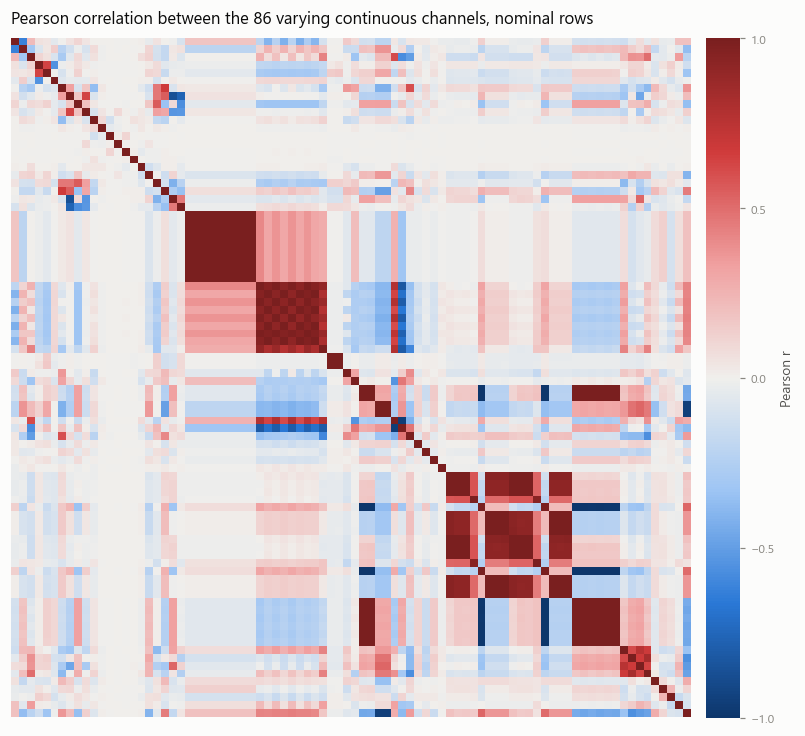

In [20]:
sd = V.loc[nominal, con_ch].std()
numeric = [c for c in con_ch if sd[c] > 1e-9]
dropped = [c for c in con_ch if sd[c] <= 1e-9]
print(f"numeric channels with variance in nominal operation: {len(numeric)} "
      f"of {len(con_ch)}")
if dropped:
    print("  dropped as constant:", ", ".join(dropped))

# Pandas computes each pair on the rows where both channels are present, so the
# lead-in from section 4 narrows the sample for channel_4, 56 and 57 rather than
# voiding their coefficients.
corr = V.loc[nominal, numeric].corr()          # method="pearson" is the default

fig, ax = plt.subplots(figsize=(8.0, 6.8))
div = mpl.colors.LinearSegmentedColormap.from_list(
    "div", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f0a0a0", "#d03b3b", "#7a1f1f"])
im = ax.imshow(corr.values, cmap=div, vmin=-1, vmax=1, aspect="equal")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Pearson correlation between the {len(numeric)} varying numeric "
             f"channels, nominal rows")
ax.grid(visible=False)
for sp in ax.spines.values():
    sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cb.set_label("Pearson r", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

vals = np.abs(corr.values[np.triu_indices(len(corr), 1)])
print(f"{len(vals):,} distinct pairs   median |r| = {np.median(vals):.3f}   "
      f"|r| > 0.8: {(vals > 0.8).mean():.1%}   |r| > 0.5: {(vals > 0.5).mean():.1%}")

off = corr.where(~np.eye(len(corr), dtype=bool)).stack().sort_values(key=abs, ascending=False)
seen, top = set(), []
for (i, j), v in off.items():
    if (j, i) in seen:
        continue
    seen.add((i, j)); top.append((i, j, float(v)))
    if len(top) == 10:
        break
sub = dict(zip(meta.Channel, meta.Subsystem))
print("\nmost strongly correlated pairs:")
for i, j, v in top:
    same = "same subsystem" if sub.get(i) == sub.get(j) else "across subsystems"
    print(f"   {i:<12} ~ {j:<12} r = {v:+.4f}   {same}")

**The strongest correlations are real but degenerate.** Every one of the ten highest
pairs sits at `r = +1.0000`, and all of them are among channels 29 to 37 -- the same
block that section 3 found to be the most static of all, changing on three rows in a
million.

They are not an artefact of the resampling: those channels report at the full
18-second rate, so the coincidence of their steps is in the telemetry and not in the
grid. But a coefficient computed on a column with two or three distinct values is not
measuring the strength of a linear relationship; it is recording that two near-binary
signals switch at the same instants. Nine channels that flip together are most
plausibly one underlying discrete state reported nine times, and whatever a
covariance-based model takes from that block, it is one fact rather than thirty-six
pairwise ones.

Discount that block and the picture is one of **sparse coupling**: the median
absolute correlation across 3,655 pairs is **0.067**, and only **5.2%** exceed 0.8.
For most pairs of channels there is no linear relationship to speak of, which is
what one would expect of a spacecraft whose subsystems are largely independent —
and it sets a low ceiling on what a covariance-based model has to work with.

### Cramer's V, on the categorical channels

Pearson on a three-level status word measures nothing useful, so the categorical
channels are compared on their contingency table instead. **Cramer's V** is the
measure reported: `sqrt(chi2 / (n * (min(rows, cols) - 1)))`, which carries the same
ordering as the chi-square statistic on a scale that reads 0 to 1. The normalisation
matters more here than it would elsewhere, because these tables are 2x2, 2x3, 3x3 and
4x4 -- a raw chi-square would reward the wider ones for being wider.

categorical channels: 10   varying in nominal operation: 9
Cramer's V computed over 9 columns (36 pairs), n = 5,789,175 rows
most strongly associated pairs in nominal operation:
   channel_55   ~ channel_54   V = 0.707
   channel_53   ~ channel_50   V = 0.448
   channel_50   ~ channel_51   V = 0.358
   channel_51   ~ channel_53   V = 0.308
   channel_51   ~ channel_52   V = 0.290
   channel_55   ~ channel_53   V = 0.263
   channel_53   ~ channel_54   V = 0.263
   channel_52   ~ channel_53   V = 0.252

36 distinct pairs   median V = 0.056   V > 0.8: 0.0%   V > 0.5: 2.8%


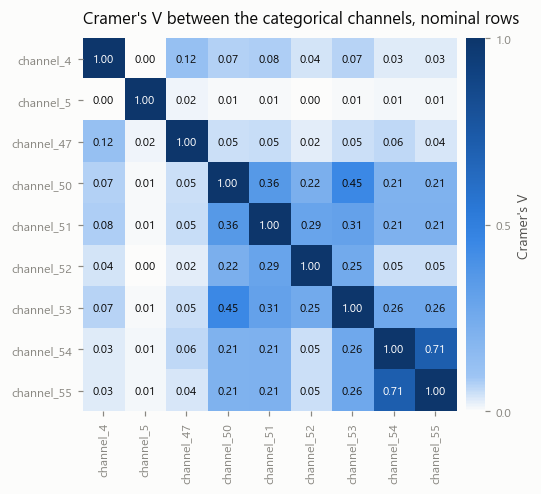

In [21]:
from scipy.stats import chi2_contingency

cram_cols = [c for c in cat_ch if K[c].nunique() > 1]
n_nom = len(K)
cram = pd.DataFrame(np.eye(len(cram_cols)), index=cram_cols, columns=cram_cols)
for i, a_ in enumerate(cram_cols):
    for b_ in cram_cols[i + 1:]:
        table_ = pd.crosstab(K[a_], K[b_])
        stat = chi2_contingency(table_)[0]
        v = float(np.sqrt(stat / (n_nom * (min(table_.shape) - 1))))
        cram.loc[a_, b_] = cram.loc[b_, a_] = v

print(f"categorical channels: {len(cat_ch)}   varying in nominal operation: "
      f"{len(cram_cols)}")
print(f"Cramer's V computed over {len(cram_cols)} columns "
      f"({len(cram_cols) * (len(cram_cols) - 1) // 2} pairs), n = {n_nom:,} rows")

fig, ax = plt.subplots(figsize=(5.6, 4.6))
seq = mpl.colors.LinearSegmentedColormap.from_list("seq", ["#fcfcfb"] + SEQ[2:])
im = ax.imshow(cram.values, cmap=seq, vmin=0, vmax=1, aspect="equal")
ax.set_xticks(range(len(cram_cols)), cram_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(cram_cols)), cram_cols, fontsize=8)
for i in range(len(cram_cols)):
    for j in range(len(cram_cols)):
        v = cram.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="#ffffff" if v > 0.6 else INK)
ax.set_title("Cramer's V between the categorical channels, nominal rows")
ax.grid(visible=False)
for sp in ax.spines.values():
    sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, ticks=[0, 0.5, 1])
cb.set_label("Cramer's V", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

off = cram.where(~np.eye(len(cram), dtype=bool)).stack().sort_values(ascending=False)
seen, top_v = set(), []
for (i, j), v in off.items():
    if (j, i) in seen:
        continue
    seen.add((i, j))
    top_v.append((i, j, float(v)))
    if len(top_v) == 8:
        break
print("most strongly associated pairs in nominal operation:")
for i, j, v in top_v:
    print(f"   {i:<12} ~ {j:<12} V = {v:.3f}")
flat = cram.to_numpy()[np.triu_indices(len(cram), 1)]
print()
print(f"{len(flat)} distinct pairs   median V = {np.median(flat):.3f}   "
      f"V > 0.8: {(flat > 0.8).mean():.1%}   V > 0.5: {(flat > 0.5).mean():.1%}")
del K

**One pair stands out and the rest is sparse.** `channel_54 ~ channel_55` reaches
**V = 0.707**, and it is the only pair above 0.5 out of 36. Both take three levels and
both sit in the same subsystem; their dominant states differ, 2 against 1, while their
dominant shares are identical to four decimals at 0.7370 -- which is what two
complementary views of one three-position mechanism look like.

Below that the matrix is nearly empty: the median V is **0.056**, and `channel_4` and
`channel_5` are independent of everything, including each other, at V = 0.00. The
categorical side of ESA is not a coupled system. That is the opposite of HAI, where
five of the six varying tags turned out to be one switch reported five times, and it
means the ten categorical channels here carry close to ten independent facts rather
than one repeated.

---
## 7. Summary

**The dataset.** Real satellite telemetry, 100 channels over three and a half
years, expert-annotated. Delivered as separate per-channel series on irregular
indices; the table analysed here is the result of putting them on one 18-second
grid with zero-order hold and materialising the interval annotations as columns.

**What has to be handled.**

| issue | detail |
|---|---|
| no table in the raw data | 100 channels on independent irregular indices, sampling rates differing by 4,300x |
| the first 58 days are incomplete | two channels report for the first time on 28 February 2000, and their lead-in is left NaN rather than imputed |
| labels are intervals, not a column | `(ID, Channel, StartTime, EndTime)` plus a category, materialised per row by the preprocessing |
| 613 of 644 annotations are not anomalies | `Rare Event` is unusual but nominal; treating it as a positive changes the task |
| a third of the channels are near-constant | 29 channels change on under one row in a thousand while reporting at full rate: discrete states, not slow signals |
| the grid discards readings | 18 s is the modal native rate, but `channel_63`-`channel_65` sample at 3 s and lose 81% of their readings to it |
| one anomaly dominates the row count | per-row metrics measure that single event; per-segment metrics do not |
| the anomalous rows sit in two months | December 2000 and January 2001 hold 88% of them, from three events out of 31 |
| the anomalies are front-loaded | 21 of 31 start in 2000, so a chronological split yields two halves with very different base rates |

**What makes it tractable.**

- The annotation is **per channel**, which no other dataset in this project
  provides: it makes attribution measurable rather than merely plausible.
- Annotations are overwhelmingly **multivariate and global** — 635 of 644 touch
  several channels at once — and the anomalies themselves have a median of five
  channels each. That is the regime a coupling-based method is built for.
- But the strongest correlations in the table are **degenerate rather than
  informative**: nine near-binary channels switching together, not a relationship a
  covariance model can use. See section 6.
- The recording is **numeric and long**, so the amount of training data is a
  parameter rather than a constraint.
- The incompleteness is **free to discard**: the first anomaly begins 1.9 days
  after the last channel comes online, so cutting the 58-day lead-in costs 4.6% of
  the rows and none of the 31 anomaly segments.